# Stage 0: Business Understanding

## Problem Statement
The objective of this project is to build **MovieIQ** a machine learning model that predicts whether a movie will be commercially successful based on features such as budget, popularity, runtime, vote average and genre.

### Success Definition
A movie is considered **successful** if:
- **Success (1):** Revenue > Budget
- **Failure (0):** Revenue =/< Budget

### Business Value
Predicting movie success helps stakeholders such as **film studios** and **investors** make informed decisions regarding production budgets, marketing strategies, and investment opportunities while reducing financial risk.

### Project Objectives
- Prepare and clean the movie dataset.
- Perform exploratory data analysis (EDA).
- Conduct statistical tests to identify significant factors.
- Train a Random Forest classifier to predict movie success.
- Build an interactive Streamlit dashboard for data visualization and prediction.

### Problem Type
This is a **Binary Classification** problem where the target variable is **`success`** indicating whether a movie is commercially successful (1) or unsuccessful (0).

# Stage 1: Data Preparation

In this stage, we load the dataset, inspect its structure, identify missing or invalid values, and prepare the data for analysis and machine learning. We also create the target variable (`success`) that will be used for prediction.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [39]:
# LOADING THE DATASET 

df = pd.read_csv(r"C:\Users\Shlok\Downloads\movies.csv")


In [40]:
df.head()
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
df.info()

Rows    : 2000
Columns : 7
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   str    
 6   genres        2000 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 185.8 KB


## Summary Statistics

Descriptive statistics provide an overview of the numerical features, including measures such as mean, min, max and standard deviation

In [41]:
df.describe()
df.isnull().sum()
print("Duplicate Rows :", df.duplicated().sum())
print("Budget = 0 :", (df["budget"] == 0).sum())
print("Revenue = 0 :", (df["revenue"] == 0).sum())

Duplicate Rows : 0
Budget = 0 : 0
Revenue = 0 : 0


## Create Target Variable

A new binary target variable named **success** is created. A movie is labeled as successful (1) if its revenue exceeds its budget (**REVENUE > BUDGET**) otherwise it is labeled unsuccessful (0)

In [42]:
df["Success"]= np.where(df["revenue"] > df["budget"], 1, 0)

df.head()

,budget,revenue,popularity,runtime,vote_average,title,genres,Success
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",1
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]",1
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",1
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]",0
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",1


## Class Distribution

The distribution of successful and unsuccessful movies is examined to determine whether the dataset is balanced

In [43]:
df["Success"].value_counts()
df["Success"].value_counts(normalize=True) * 100


Success
1    80.7
0    19.3
Name: proportion, dtype: float64

## Genre Inspection

The genres column contains one or more genres for each movie we inspect its values to understand how genre information is stored before processing it for analysis

In [44]:
df["genres"].head(10)

0    [{'id': 10749, 'name': 'Romance'}]
1         [{'id': 18, 'name': 'Drama'}]
2        [{'id': 35, 'name': 'Comedy'}]
3         [{'id': 18, 'name': 'Drama'}]
4        [{'id': 35, 'name': 'Comedy'}]
5    [{'id': 10749, 'name': 'Romance'}]
6     [{'id': 12, 'name': 'Adventure'}]
7        [{'id': 28, 'name': 'Action'}]
8        [{'id': 27, 'name': 'Horror'}]
9        [{'id': 27, 'name': 'Horror'}]
Name: genres, dtype: str

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, trends amd relationships within the movie dataset. In this stage  we analyze how different movie attributes such as budget, revenue, popularity, runtime, vote average, and genre relate to commercial success. The insights gained here will guide feature selection and support our  machine learning model

## Budget vs Revenue Analysis

This scatter plot examines the relationship between a movie's production budget and the revenue it generates. It helps determine whether movies with higher budgets tend to earn higher revenues

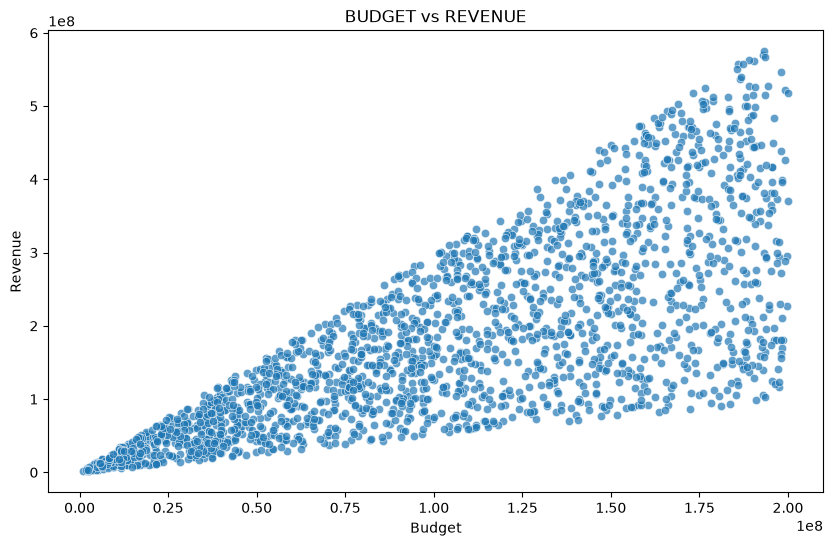

In [45]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    alpha=0.7
)
plt.title("BUDGET vs REVENUE")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

The scatter plot shows a clear positive correlation between movie budgets and revenues meaning higher investments generally lead to higher earnings, though not always proportionally. Some high-budget films underperform highlighting financial rizk while a few low-budget films achieve exceptional revenues, showing blockbuster surprises.

## Success Distribution

The following chart shows the number of successful and unsuccessful movies in the dataset. This helps us understand whether the dataset is balanced.

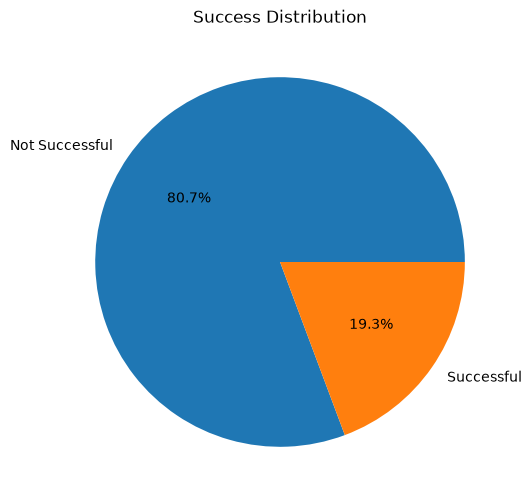

In [46]:
plt.figure(figsize=(6,6))
df["Success"].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["Not Successful","Successful"],
)
plt.title("Success Distribution")
plt.ylabel("")
plt.show()


The chart shows that about **80% of movies in the dataset are successful** while only **20% are not**. This highlights a strong skew toward profitability, suggesting either that most films manage to earn more than their budget or that the dataset emphasizes commercially viable titles.

## Genre Distribution

Movies may belong to multiple genres so we split the genre values to identify the most common genres in our dataset

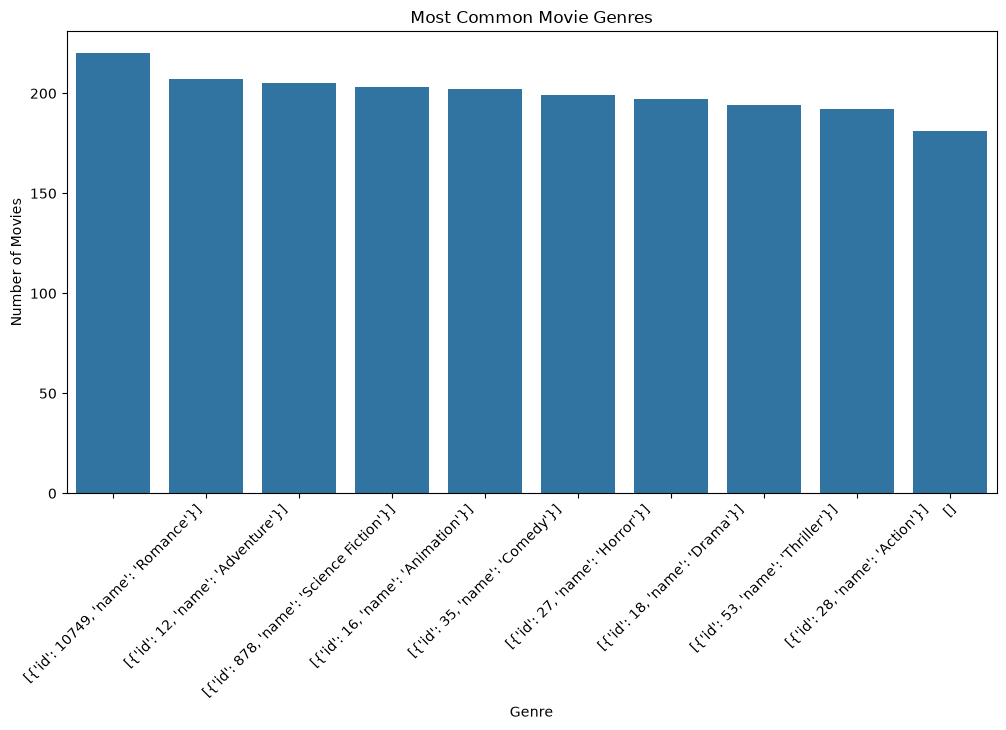

In [47]:
genre_counts = (
    df["genres"].str.split("|")
      .explode()
      .value_counts()
)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.xticks(rotation=45)
plt.title("Most Common Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()


## The chart shows tht Romance is the most common genre w slightly over 220 movies followed by Adventure, Sci‑Fi, Animation, Comedy, Horror, Drama, and Thriller. Action appears least frequent just under 190 movies 

## Popularity and Movie Success

This box plot compares the popularity scores of successful and unsuccessful movies to determine whether popularity is associated with commercial success.

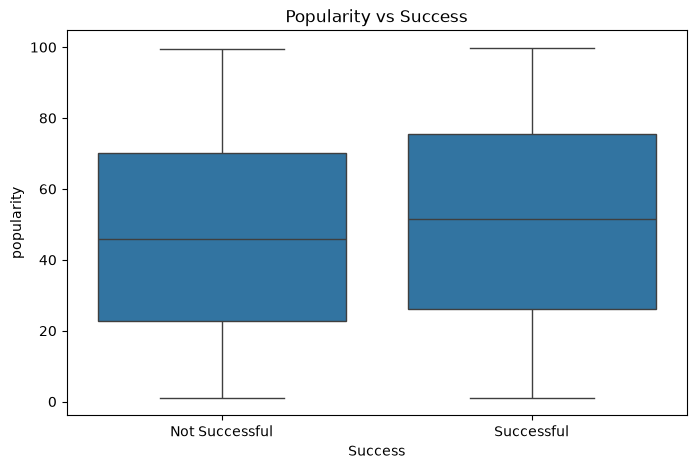

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Success",
    y="popularity"
)

plt.xticks([0,1],["Not Successful","Successful"])
plt.title("Popularity vs Success")
plt.show()

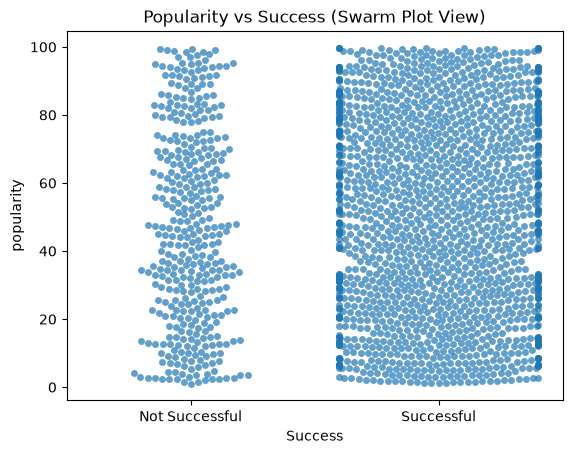

In [49]:
sns.swarmplot(
    data=df,
    x="Success",
    y="popularity",
    alpha=0.7
)
plt.xticks([0,1],["Not Successful","Successful"])
plt.title("Popularity vs Success (Swarm Plot View)")
plt.show()


## While boxplots show that successful movies have a slightly higher median popularity the swarm plot reveals the full distribution highlighting clusters around mid‑popularity amd  a few extreme cases at both ends

## Runtime and Movie Success

This visualization examines whether movie duration influences the movies's success

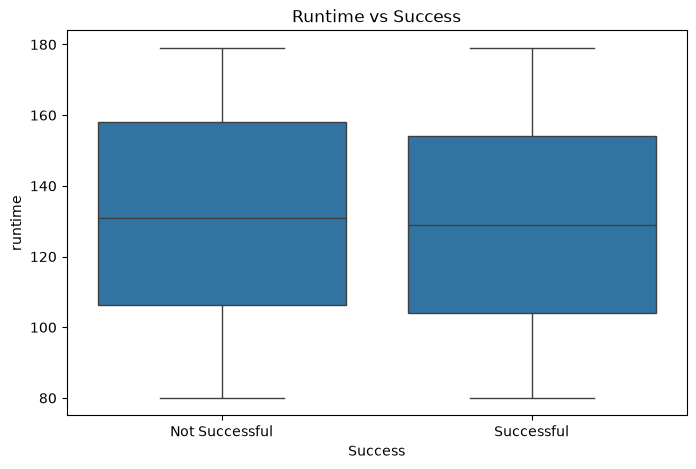

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Success",
    y="runtime"
)
plt.xticks([0,1],["Not Successful","Successful"])
plt.title("Runtime vs Success")
plt.show()

## The boxplot shows that movie runtimes are distributed almost identically for both successful nd not successful films hving  similar medians and ranges nd indicating that runtime length does not significantly influence commercial success—other factors like budget, popularity or ratings are more decisive.

## Audience Ratings and Success

This analysis compares audience ratings between successful and unsuccessful movies to understand whether higher-rated movies tend to perform better commercially.

<Axes: xlabel='Success', ylabel='vote_average'>

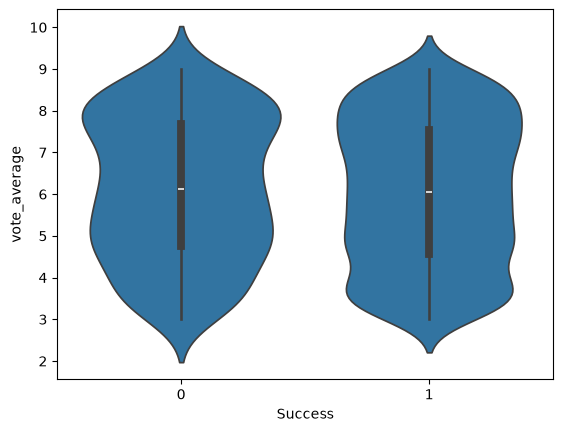

In [51]:
sns.violinplot(data=df, x="Success", y="vote_average")

## Successful movies tend to have higher average ratings but vote average by itself is not a definitive predictor of success

## Correlation Analysis

A correlation heatmap helps identify the strength of relationships between numerical features and highlights potential multicollinearity before model building,

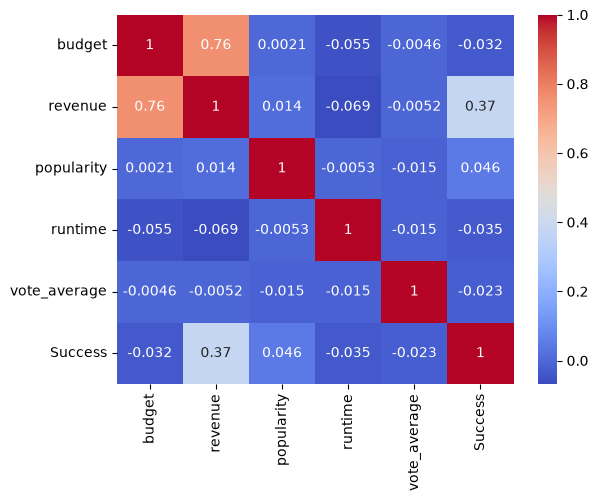

In [52]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


## Budget vs Revenue (0.76) -- Strong positive correlation i.e bigger budgets tend to generate higher revenues.

## Revenue vs Success (0.37) -- Moderate positive correlation i.e higher revenues are linked to greater chances of success.\

## Popularity, Runtime, Vote Average -- Weak or near‑zero correlations with success meaning these factors don’t strongly drive commercial outcomes

## Negative or near‑zero values -- Indicate little to no relationship between variables.

## Pairwise Feature Relationships

A pairplot provides a comprehensive view of relationships btw numerical variables and helps identify natural clusters or separations between successful and unsuccessful movies.

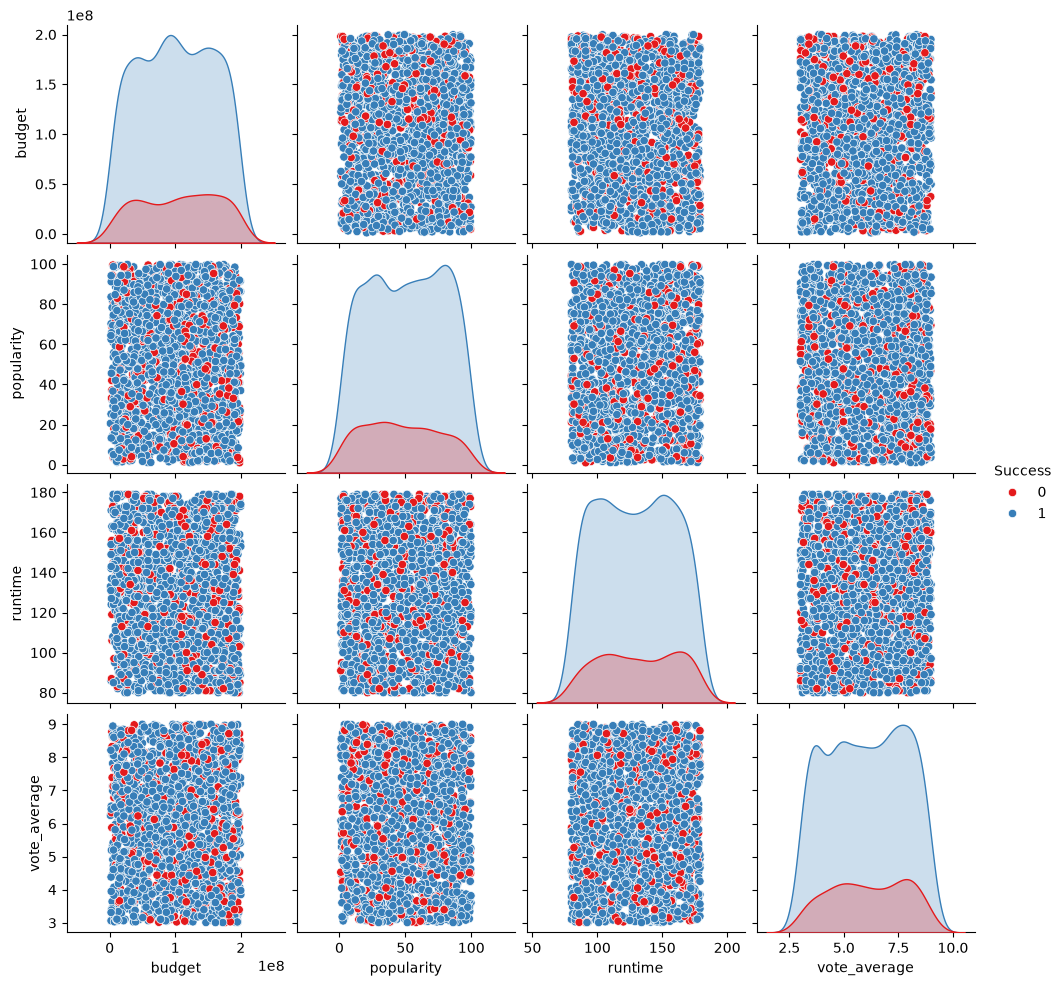

In [53]:
sns.pairplot(
    df,
    vars=["budget","popularity","runtime","vote_average"],
    hue="Success",
    palette="Set1"
)

plt.show()

# Stage 3: Statistical Testing

Statistical testing helps determine whether the patterns observed during exploratory data analysis are statistically significant or occurred by chance. In this stage we perform hypothesis testing using an Independent **T-Test** and a **Chi-Square** Test to evaluate the relationship between movie features and commercial success

In [54]:
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

## Independent T-Test

The Independent T-Test is used to determine whether the average popularity differs significantly between successful and unsuccessful movies.

### Null Hypothesis:
There is no significant difference in the average popularity of successful and unsuccessful movies.

### Alternative Hypothesis: 
There is a significant difference in the average popularity of successful and unsuccessful movies.

In [55]:
# First we go on seprating the 2 groups

successful = df[df["Success"] == 1]["popularity"]
unsuccessful = df[df["Success"] == 0]["popularity"]

# Now we Perform Independent T-Test

t_stat, p_value = ttest_ind(successful, unsuccessful)

print("T-Statistic :", round(t_stat,4))
print("P-Value :", round(p_value,5))

T-Statistic : 2.0647
P-Value : 0.03908


In [56]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("Popularity differs significantly between successful nd unsuccessful movies")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No significant difference found")

Reject the Null Hypothesis
Popularity differs significantly between successful nd unsuccessful movies


## Chi-Square Test
The Chi-Square Test is used to determine whether movie genre is associated with commercial success basically does movie success depend on genre?

### Null Hypothesis:
Movie genre and commercial success are independent.

### Alternative Hypothesis:
Movie genre and commercial success are associated.

In [57]:
# Split genres

genre_df = (df.assign(genres=df["genres"].str.split("|")).explode("genres"))

# Creating a frequency table
dedicated_table = pd.crosstab(
    genre_df["genres"],
    genre_df["Success"]
)

dedicated_table

Success,0,1
genres,,
[],34,147
"[{'id': 10749, 'name': 'Romance'}]",42,178
"[{'id': 12, 'name': 'Adventure'}]",41,166
"[{'id': 16, 'name': 'Animation'}]",38,165
"[{'id': 18, 'name': 'Drama'}]",35,162
"[{'id': 27, 'name': 'Horror'}]",36,163
"[{'id': 28, 'name': 'Action'}]",41,151
"[{'id': 35, 'name': 'Comedy'}]",38,164
"[{'id': 53, 'name': 'Thriller'}]",37,157


In [58]:
chi2, p_value, dof, expected = chi2_contingency(dedicated_table)

print("Chi-Square Statistic :", round(chi2,4))
print("P-Value :", round(p_value,6))
print("Degrees of Freedom :", dof)

Chi-Square Statistic : 1.7731
P-Value : 0.994569
Degrees of Freedom : 9


## Chi‑Square Statistic (1.77):
Very small, meaning the observed counts across genres are close to what we’d expect if success and genre were independent

## Degrees of Freedom (9):
Comes from the number of genres minus one.

## P‑Value (0.9946):
Extremely high far above 0.05.

In [59]:
alpha = 0.05
if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("Movie genre has a significant association with commercial success.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("Movie genre does not have a significant association with commercial success.")

Fail to Reject the Null Hypothesis
Movie genre does not have a significant association with commercial success.


# Stage 4: Machine Learning

In this stage a **Random Forest Classification model** is developed to predict whether a movie will be commercially successful or not. The dataset is prepared by selecting relevant features, splitting it into training and testing sets, training the model and evaluating its performance using multiple metrics


In [60]:
# importing necessary libraries 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Feature Selection

Relevant numerical features are selected as input. The target variable is **success**, which indicates whether a movie is commercially successful or not successful 

In [61]:
#preparing your dataset by splitting it into features (X) and target (y) and
# then previewing the features to confirm they’re correct

# feature
X = df[["budget","popularity","runtime","vote_average"]]

#target
y = df["Success"]

print(X.head())

      budget  popularity  runtime  vote_average
0   57755036   60.377360       98      6.611888
1  192100010   86.289857       96      7.184687
2  128521863   86.995324      148      3.542978
3  156299516   72.710096      118      5.985176
4  148532820   74.829585      161      4.578480


# Why are we not using revenue?
its Because the target (success) is defined using **revenue > budget** and including revenue would cause data leakage allowing the model to **cheat**

## Train-Test Split
The dataset is divided into training and testing sets using an 80:20 ratio. The training set is used to train the model while the testing set is reserved for evaluating its performance.

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (1600, 4)
Testing Samples : (400, 4)


## Model Training

A Random Forest Classifier is trained using the training dataset. Random Forest is chosen because it is robust, handles **non-linear relationships effectively** and reduces the risk of overfitting by combining multiple decusion trees

In [63]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Model Prediction

The trained model is used to predict the commercial success of movies in the testing dataset

In [64]:
y_pred = rf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## Model Performance

The model is evaluated using Accuracy, Precision, Recall, and F1-Score to assess its classification performance.

In [65]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7850
Precision: 0.7964
Recall   : 0.9812
F1 Score : 0.8792


## Accuracy: 0.7850 (78.5%)  
Out of all predictions about 79% were correct. A good overall measure but can be misleading if classes are imbalanced.

# Precision: 0.7964 (79.6%)
of all movies the model predicted as successful **80%** were actually successful. High precision means fewer false positives.

## Recall: 0.9812 (98.1%)  
of all movies that were truly successful **98%** were correctly identified. Very high recall means the model rarely misses successful movies (few false negatives).

## F1 Score: 0.8792 (87.9%)  
Harmonic mean of precision and recall.Balances the trade‑off between catching most successes (recall) and being accurate when predicting success (precision)

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.14      0.01      0.02        81
           1       0.80      0.98      0.88       319

    accuracy                           0.79       400
   macro avg       0.47      0.50      0.45       400
weighted avg       0.66      0.79      0.71       400



## Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing actual and predicted class labels, highlighting correct and incorrect classifications.

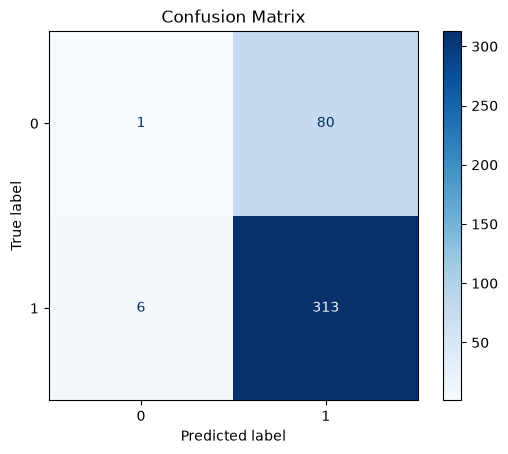

In [67]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test,cmap="Blues")
plt.title("Confusion Matrix")

plt.show()

## True Negatives (1) = Only 1 movie that was actually unsuccessful was correctly predicted as unsuccessful.

## False Positives (80) = 80 movies that were actually unsuccessful were wrongly predicted as successful.

## False Negatives (6) = 6 movies that were actually successful were wrongly predicted as unsuccessful.

## True Positives (313) = 313 movies that were actually successful were correctly predicted as successful.

## Feature Importance

Feature importance indicates how much each input variable contributes to the model's prediction. This helps identify the most influential factors affecting movie success.

In [68]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)
importance

,Feature,Importance
1,popularity,0.270826
0,budget,0.262001
3,vote_average,0.261316
2,runtime,0.205857


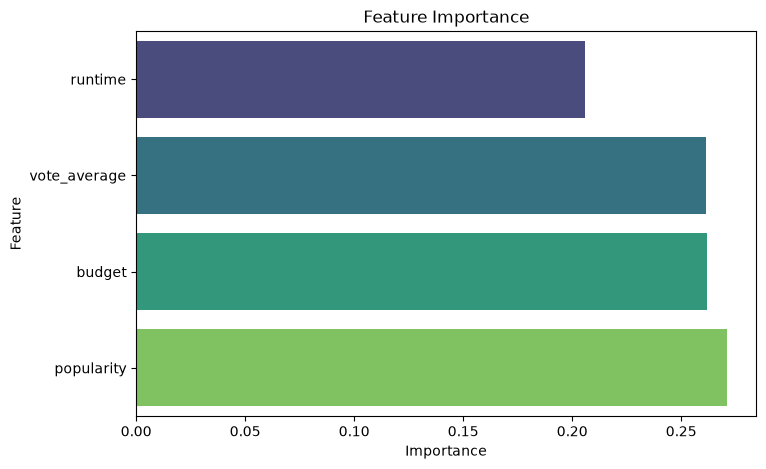

In [69]:
plt.figure(figsize=(8,5))
importance_sorted = importance.sort_values("Importance", ascending=True)

sns.barplot(
    data=importance_sorted,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance")
plt.show()


## Stage 4 Summary

A Random Forest Classification model was trained to predict movie success using budget, popularity, runtime, and vote average as predictor variables. The model was evaluated using multiple classification metrics, and feature importance analysis was performed to identify the variables that contribute most to prediction accuracy.

In [70]:
import joblib

# Save the trained model in the project root  i.e takes the trained model from memory and writes it to a file in our computer
joblib.dump(rf, "../../random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [71]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

feature_importance

,Feature,Importance
1,popularity,0.270826
0,budget,0.262001
3,vote_average,0.261316
2,runtime,0.205857
